# Metaheurística - Parte 1: Elementos asociados al _NSGA-II_.
Dentro del presente _notebook_ se realiza la definición de los elementos fundamentales asociados al algoritmo _NSGA-II_ que es el algoritmo

## Definición de codificación de soluciones.
En este bloque se presenta la codificación de las soluciones asociadas al algoritmo de _clustering_ tomando en cuenta: **La carga de matrices de expresión, generación de población inicial, función objetivo, mecanismos de interacción (selección, crossover y mutación) y funciones de estudio de soluciones** con el fin de proporcionar las herramientas más fundamentales en la creación de la variante de _NSGA-II_ mostrada en el trabajo _A multi-objective gene clustering algorithm guided by apriori biological knowledge with intensification and diversification strategies_; aunque salvando ciertas libertades en post de la eficiencia de ejecución de esta misma.


In [1]:
#######################################################
# MODULO DE DEFINICIÓN DE CODIFICACIÓN DE LA SOLUCIÓN
# En el presente bloque de código se definen las funciones fundamentales para la
# codificación y cálculo de la función objetivo dentro de la metaheurística.
#######################################################

############################
# Importaciones
############################
import os                                                   # Llamadas al SO.
import numpy  as np                                         # Aplicación de operaciones matematicas eficientes.
import pandas as pd                                         # Lectura de conjuntos de datos en csv.
from pathlib import Path                                    # Aplicar un formato generalizado de direcciones en el script.

############################
# Variables globales
############################
OBJ_FUNCTION_CALLS = 0                                      # Se define variables para administrar las llamadas a función objetivo y dar fin a ejecución.

##################################
# Configuraciones
##################################
# Se realiza la verificación de que sea posible el uso de CuPy
# con el fin de priorizar cálculo paralelo.
try:
    import cupy as cp
    _GPU = True
    print("[backend] CuPy detectado → operaciones vectorizadas en GPU.")
except ImportError:
    cp = np          # alias: mismo API que NumPy
    _GPU = False
    print("[backend] CuPy no encontrado → usando NumPy (CPU).")

############################
# Constantes
############################
DE_DIR  = Path(os.getcwd()).resolve().parent.parent / "Datasets" / "Matrices" / "A2_S_DE.csv"
DB_DIR  = Path(os.getcwd()).resolve().parent.parent / "Datasets" / "Matrices" / "A2_S_DB.csv"
SOL_DIR = Path(os.getcwd()).resolve().parent.parent / "Results" / "moc_gapbk_pareto_clusters.csv"

def load_distance_matrix(filepath: Path) -> tuple[np.ndarray, list[str]]:
    """
    Lee los archivos csv generados en la étapa de pre-procesamiento de los datasets cambiando
    su formato de matrices de distancia, dado a que en la étapa anterior se tomaban como
    de similitud para su gráficación y filtrado.
    """

    # La primera columna y fila siempre es el índice de genes, por ende, se puede
    # ignorar la primera columna y extraer el identificador de genes de la segunda.
    df = pd.read_csv(filepath, index_col=0)
    gene_names = df.index.astype(str).tolist()

    # Extracción de valores de las matrices.
    matrix = 1 - df.values.astype(np.float64)

    # Retroalimentación de carga.
    print(
        f"[load] '{filepath.name}' → matriz {matrix.shape[0]}×{matrix.shape[1]} cargada. "
        f"Primer gen: '{gene_names[0]}', último: '{gene_names[-1]}'."
    )
    return matrix, gene_names

def random_medoids_pop(n: int, k: int, pop_size: int = 1, seed: int | None = None) -> np.ndarray:
    """
    Construcción de la población inicial a través del uso de de funciones psudoaleatorias
    de construcción de arreglos.
    """
    # Se inicializa la interfaz de seleccuión de número psudoaleatorios.
    rng = np.random.default_rng(seed)

    # Generación de 'n' arreglos de tamaño 'k' mediante la selección del
    # índice asociado al gen. 
    population = np.stack(
        [rng.choice(n, size=k, replace=False) for _ in range(pop_size)]
    ).astype(np.int32)

    return population

def build_clusters_population(
    distance_matrix: np.ndarray,
    population: np.ndarray,
) -> np.ndarray:
    """
    Construcción de matrices del formato de medoides al formato de labels,
    para una población completa de individuos en una sola operación vectorizada.
    """
    xp  = cp if _GPU else np          # backend activo

    # Transformación de elementos numpy a matrices manejables por GPU, siendo
    # su equivalente, es decir, D es una matriz cuadrada de orden 'g' genes y 
    # population es un arreglo de 'n' soluciones de 'k' medoides cada una.
    D   = xp.asarray(distance_matrix)
    pop = xp.asarray(population)

    # Submatriz de distancia que representa la distancia de cada gen
    # de la población a los respectivos medoides de cada uno de los
    # arreglos de medoides para la asignación.
    # Coordenadas: [gen, solución, medoide].
    D_pop = D[:, pop]
    
    # Cluster más cercano para cada elemento, por individuo (0-based).
    # Coordenadas: [gen, indice de medoide].
    labels_xp = xp.argmin(D_pop, axis=-1)

    # Reordenar a (pop_size, n) y pasar a 1-based.
    # Coordenadas: [solución, asignación de cluster]
    # Se cambia la asignación a <indice de cluster> + 1.
    labels_xp = labels_xp.T                 # (pop_size, n)

    if _GPU:
        return cp.asnumpy(labels_xp).astype(np.int32) + 1
    return labels_xp.astype(np.int32) + 1

def xie_beni(
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
    medoids: np.ndarray,
    labels:  np.ndarray,
) -> tuple[float, float]:
    """
    Calcula los índices Xie-Beni de expresión (XB_GE) y de información (XB_BI)
    para una solución individual, en una sola operación vectorizada.

    Considerar que la fórmula de Xie-beni (XB) definida en el trabajo de referencia es:
    XB(C) = (Sumatoria TODAS las distancias al cuadrado entre los elementos de un cluster a su respectivo medoide)
     / (numero total de elementos) por (Distancia minima entre un par de medoides).

    Parámetros
    ----------
    deb_matrix : np.ndarray — matriz (n×n) de distancias de expresión   (DEB).
    dbb_matrix : np.ndarray — matriz (n×n) de distancias de información (DBB).
    medoids    : np.ndarray — arreglo 1-D de k índices de medoides (0-based).
    labels     : np.ndarray — labels (1-based) de build_clusters(dge_matrix, medoids).

    Retorna
    -------
    tuple[float, float] — (XBEB, XBBB). Valores menores indican mejor solución.
    Cada componente retorna np.inf si dos medoides son idénticos en esa matriz.
    """
    xp = cp if _GPU else np

    # Declaración de variable como versión global.
    global OBJ_FUNCTION_CALLS

    # Transformación de elementos a interfaz GPU.
    D_stack = xp.stack([xp.asarray(deb_matrix), xp.asarray(dbb_matrix)])    # Fusión de ambas matrices de distancia (Matriz, n, n).
    med     = xp.asarray(medoids)                                           # Población de medoides asociada (sol, medoides).
    n       = D_stack.shape[1]                                              # Cantidad de genes.
    k       = med.shape[0]                                                  # Cantidad de medoides por solución.

    # Elementos asociado a los clusters.
    cluster_idx     = labels - 1                                            # (n,)   Solución de clustering - 0-based
    medoid_per_elem = med[cluster_idx]                                      # (n,)   Asociación gen-medoide basado en el índice del gen.
    idx_mat         = xp.arange(2)[:, None]                                 # (2, 1) Indices de las dos matrices (0: expr ; 1: info).
    idx_elem        = xp.arange(n)[None, :]                                 # (1, n) Indices asociados a los elementos (genes).

    # Cálculo de distancia entre el medoide asignado según cada elemento
    # de los clusters (ambas matrices) y definición del numerador.
    dist_to_medoid  = D_stack[idx_mat, idx_elem, xp.broadcast_to(medoid_per_elem, (2, n))]
    numerator       = xp.sum(dist_to_medoid ** 2, axis=1)   # (2,)

    # Calculo del denominador (menor distancia entre clusters)
    D_med     = D_stack[:, med, :][:, :, med]                               # Sub matriz considerando los medoides.
    diag_mask = xp.eye(k, dtype=bool)                                       # Marca de diagonal (ignorar al ser 0).
    D_med_off = xp.where(diag_mask, xp.inf, D_med)                          # Aplicar infinito a las diagonales.
    min_inter = xp.min(D_med_off ** 2, axis=(1, 2))                         # Par de medoides con menor distancia.

    # Calculo vectorizado por GPU.
    if _GPU:
        numerator = cp.asnumpy(numerator)
        min_inter = cp.asnumpy(min_inter)

    # Cálculo del índice de Xie-beni de la solución considerando ambas matrices.
    xb_deb, xb_dbb = numerator / (n * min_inter)
    xb_deb = np.inf if min_inter[0] == 0.0 else float(xb_deb)
    xb_dbb = np.inf if min_inter[1] == 0.0 else float(xb_dbb)

    # Conteo de llamas a función objetivo.
    OBJ_FUNCTION_CALLS += 1

    return xb_deb, xb_dbb



[backend] CuPy detectado → operaciones vectorizadas en GPU.


In [2]:
#######################################################
# MODULO DE FUNCIONES PARA VER RENDIMIENTO
# En el presente bloque de código se definen las funciones fundamentales para la
# codificación y cálculo de la función objetivo dentro de la metaheurística.
#######################################################

############################
# Importaciones
############################                                         # Librería de creación de gráficos.
import matplotlib.pyplot as plt                                         # Renombrado: Creación de gráficos.
import biocluster.clustering.jaccard_values as jv                       # Calculo de                          


def plot_pareto_fronts(
    objectives,
    fronts: list[list[int]],
    output_dir: str | None = None,
    filename: str = "pareto_fronts.png",
    title: str = "Frentes de Pareto",
    max_fronts_highlighted: int = 5,
    show: bool = False,
) -> str | None:
    """
    Grafica los frentes de Pareto de una población en un plano bidimensional
    (XB_GE vs XB_BI), coloreando cada frente con un color distinto. El frente 
    F1 (no dominado) se conecta además con una línea punteada para visualizar 
    la forma del frente.

    Nota: Soluciones con valores no finitos (XB_GE o XB_BI = inf, correspondientes
    a soluciones degeneradas) se excluyen del gráfico.
    """
    # Definición de labels.
    XLABEL = "XB_GE (Expresión)"
    YLABEL = "XB_BI (Biológico)"

    # Transformación de objetivos a formato numpy.
    objectives = np.asarray(objectives, dtype=np.float64)

    # Configuración de mosaico.
    fig, ax = plt.subplots(figsize=(8, 6))      # Distribución de pulgadas.
    cmap = plt.get_cmap("viridis")              # Color 'viridis'.
    n_fronts = len(fronts)                      # Fronteras a gráficar.

    # Identificación y dibujo de la Fronteras.
    for rank, front in enumerate(fronts):
        pts = objectives[front]
        finite_mask = np.all(np.isfinite(pts), axis=1)
        pts_finite = pts[finite_mask]

        if len(pts_finite) == 0:
            continue

        color = cmap(rank / max(n_fronts - 1, 1))
        label = f"F{rank + 1}" if rank < max_fronts_highlighted else None

        ax.scatter(
            pts_finite[:, 0], pts_finite[:, 1],
            color=color, label=label,
            s=45, edgecolors="black", linewidths=0.5,
            zorder=n_fronts - rank,
        )

        # Conectar el frente F1 con una línea punteada para visualizar su forma.
        if rank == 0 and len(pts_finite) > 1:
            order = np.argsort(pts_finite[:, 0])
            ax.plot(
                pts_finite[order, 0], pts_finite[order, 1],
                linestyle="--", color=color, alpha=0.6, zorder=0,
            )

    # Exlusión de soluciones degeneradas.
    n_excluded = int(np.sum(~np.all(np.isfinite(objectives), axis=1)))
    if n_excluded > 0:
        title = f"{title}\n({n_excluded} soluciones degeneradas excluidas, XB=inf)"

    ax.set_xlabel(XLABEL)
    ax.set_ylabel(YLABEL)
    ax.set_title(title)
    ax.legend(loc="best", fontsize="small", title="Frentes")
    ax.grid(alpha=0.3)
    fig.tight_layout()

    saved_path = None
    if output_dir is not None:
        out_path = Path(output_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        saved_path = out_path / filename
        fig.savefig(saved_path, dpi=150)
        print(f"[save] Gráfico de frentes de Pareto guardado en: {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return str(saved_path) if saved_path is not None else None

def jaccard_population(generations_labels: list[np.ndarray]) -> list[np.ndarray]:
    """
    Calcula el índice de Jaccard entre los individuos (soluciones en
    formato de labels) de cada generación de la metaheurística, usando
    jaccard_index_solutions de biocluster, y muestra la evolución de su
    distribución en un boxplot (una caja por generación).

    Parámetros
    ----------
    generations_labels : list[np.ndarray] — una matriz (pop_size, n_genes)
                          de labels por generación, en orden cronológico
                          (salida de build_clusters_population por generación).

    Retorna
    -------
    list[np.ndarray] — por cada generación, el arreglo 1-D con los valores
    de Jaccard entre pares (i, j) con i < j (triángulo superior de la
    matriz de similitud, sin diagonal).
    """
    n_generations = len(generations_labels)
    jaccard_per_generation = []

    for labels_pop in generations_labels:
        J = jv.jaccard_index_solutions(Solutions_Matrix=labels_pop)
        pop_size = J.shape[0]
        iu = np.triu_indices(pop_size, k=1)
        jaccard_per_generation.append(J[iu])

    plt.figure(figsize=(max(6, n_generations * 0.6), 6))
    plt.boxplot(jaccard_per_generation, vert=True, positions=range(1, n_generations + 1))
    plt.xlabel("Generación")
    plt.ylabel("Índice de Jaccard")
    plt.title(f"Similitud entre individuos por generación (n={n_generations})")
    plt.grid(True, alpha=0.3)
    plt.show()

    return jaccard_per_generation

def hypervolume_from_origin(
    xb_deb_pop: np.ndarray,
    xb_dbb_pop: np.ndarray,
) -> np.ndarray:
    """
    Calcula el hipervolumen de cada solución individual respecto al punto
    de referencia (0, 0): el área del rectángulo entre el origen y el
    punto (XBEB, XBBB) de esa solución.

    A diferencia del hipervolumen estándar (mayor es mejor, respecto a un
    punto de referencia que domina a las soluciones), aquí el origen es
    el punto IDEAL (XBEB = XBBB = 0): el área representa qué tan lejos
    está la solución de ese ideal, así que MENOR hipervolumen = mejor
    solución. No requiere validación de dominancia — como XBEB, XBBB ≥ 0
    siempre, el área nunca es negativa.

    Retorna
    -------
    np.ndarray — hipervolumen (XBEB · XBBB) de cada individuo. Menor es mejor.
    """
    xb_deb_pop = np.asarray(xb_deb_pop, dtype=np.float64)
    xb_dbb_pop = np.asarray(xb_dbb_pop, dtype=np.float64)
    return xb_deb_pop * xb_dbb_pop

def plot_hypervolume_convergence(
    hv_per_generation: list[np.ndarray],
    output_dir: str | None = None,
    filename: str = "hypervolume_convergence.png",
    show: bool = False,
) -> str | None:
    """
    Muestra la convergencia de la metaheurística a partir de los valores
    de hipervolumen de cada generación (salida de hypervolume_from_origin
    aplicada sobre la población de cada generación).

    Grafica, por generación:
      - el hipervolumen promedio de la población (línea sólida),
      - el rango [mínimo, máximo] de esa generación (banda sombreada),
      - el mejor hipervolumen visto hasta esa generación (línea punteada),
        monótonamente NO creciente — el hipervolumen respecto al origen
        es un indicador "menor es mejor".
    """
    n_generations = len(hv_per_generation)
    generations = np.arange(1, n_generations + 1)

    mean_hv = np.array([np.mean(hv) for hv in hv_per_generation])
    min_hv  = np.array([np.min(hv)  for hv in hv_per_generation])
    max_hv  = np.array([np.max(hv)  for hv in hv_per_generation])
    best_so_far = np.minimum.accumulate(min_hv)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.fill_between(generations, min_hv, max_hv, color="steelblue", alpha=0.2, label="Rango [mín, máx]")
    ax.plot(generations, mean_hv, color="steelblue", marker="o", label="Promedio por generación")
    ax.plot(generations, best_so_far, color="darkorange", linestyle="--", marker="s", label="Mejor acumulado (mínimo)")

    ax.set_xlabel("Generación")
    ax.set_ylabel("Hipervolumen (menor es mejor)")
    ax.set_title("Convergencia del hipervolumen")
    ax.legend(loc="best", fontsize="small")
    ax.grid(alpha=0.3)
    fig.tight_layout()

    saved_path = None
    if output_dir is not None:
        out_path = Path(output_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        saved_path = out_path / filename
        fig.savefig(saved_path, dpi=150)
        print(f"[save] Gráfico de convergencia guardado en: {saved_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return str(saved_path) if saved_path is not None else None

In [3]:
##################################
# Bloque de ejecución
##################################
K        = 4       # número de clusters (medoides por individuo)
POP_SIZE = 100     # tamaño de la población
SEED     = 42      # semilla para reproducibilidad

# ── 1. Carga de matrices DEB/DBB ────────────────────────────────────────────
deb_matrix, gene_names = load_distance_matrix(DE_DIR)
dbb_matrix, _          = load_distance_matrix(DB_DIR)
n = deb_matrix.shape[0]

# ── 2. Formato de solución: población de arreglos de medoides ──────────────
population = random_medoids_pop(n=n, k=K, pop_size=POP_SIZE, seed=SEED)

# ── 3. Cambio de formato: medoides → labels, para toda la población ────────
labels_deb_pop = build_clusters_population(deb_matrix, population)
labels_dbb_pop = build_clusters_population(dbb_matrix, population)

##################################
# Resultados por pantalla
##################################
print(f"n genes = {n}  |  k medoides = {K}  |  población = {POP_SIZE}\n")

OBJ_FUNCTION_CALLS = 0
for i, medoids in enumerate(population):
    xb_deb, xb_dbb = xie_beni(
        deb_matrix, dbb_matrix,
        medoids,
        labels_deb_pop[i]
    )

    print(f"── Individuo {i + 1} ──")
    print(f"Medoides : {medoids.tolist()}  →  {[gene_names[idx] for idx in medoids]}")
    print(f"XBGE = {xb_deb:.6f}" + ("  (degenerada)" if xb_deb == np.inf else ""))
    print(f"XBBI = {xb_dbb:.6f}" + ("  (degenerada)" if xb_dbb == np.inf else ""))
    print()

print(f"Llamadas totales a la función objetivo: {OBJ_FUNCTION_CALLS}")

[load] 'A2_S_DE.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
[load] 'A2_S_DB.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
n genes = 288  |  k medoides = 4  |  población = 100

── Individuo 1 ──
Medoides : [126, 25, 187, 221]  →  ['INCENP', 'LARGE2', 'PCDHGA9', 'TRPC3']
XBGE = 0.708679
XBBI = 1.618582

── Individuo 2 ──
Medoides : [198, 57, 27, 151]  →  ['PLEKHA2', 'EBF1', 'LRIG3', 'MRC1']
XBGE = 1.566777
XBBI = 1.937852

── Individuo 3 ──
Medoides : [204, 147, 224, 36]  →  ['SLC39A8', 'FOXO4', 'UBE2E2', 'CRYAB']
XBGE = 8.586521
XBBI = 3.189309

── Individuo 4 ──
Medoides : [105, 225, 52, 265]  →  ['C16orf54', 'MANF', 'NSUN5P1', 'GLB1L2']
XBGE = 1.455118
XBBI = 1.214365

── Individuo 5 ──
Medoides : [65, 129, 126, 155]  →  ['SKA1', 'MIA3', 'INCENP', 'MUC3A']
XBGE = 9.490260
XBBI = 5.726666

── Individuo 6 ──
Medoides : [79, 245, 18, 237]  →  ['BICD2', 'PIP5K1B', 'FOXN3', 'TET1']
XBGE = 3.591030
XBBI = 1.893212

── Individuo 7 ──
Medoides :

In [4]:
#######################################################
# MODULO INTERACCIÓN ENTRE SOLUCIONES
# En el presente bloque de código se definen las funciones fundamentales para la
# codificación y cálculo de la función objetivo dentro de la metaheurística.
#######################################################

def _repair_duplicates(individual: np.ndarray, n: int, rng: np.random.Generator) -> np.ndarray:
    """
    Repara un cromosoma reemplazando valores duplicados por índices válidos no usados.

    Recorre el cromosoma de izquierda a derecha; la primera ocurrencia de cada valor 
    se mantiene, las ocurrencias repetidas se sustituyen por un índice aleatorio en 
    [0, n-1] que no esté ya presente en el cromosoma.
    """
    repaired = individual.copy()                            # Copia del individuo para modificación.
    seen = set()                                            # Arreglo de indices de genes vistos tanto en la solución como en la reparación.
    used = set(individual.tolist())                         # Arreglo de indices de genes ya usados en reparación.

    # Genes disponibles puestos en un conjunto aleatorio.
    available = [i for i in range(n) if i not in used]
    rng.shuffle(available)

    # Reparación.
    for i, val in enumerate(repaired):
        if val in seen:
            new_val = available.pop()
            seen.add(new_val)
            used.add(new_val)
            repaired[i] = new_val
        else:
            seen.add(val)

    return repaired

def k_point_crossover(
    parent1: np.ndarray,
    parent2: np.ndarray,
    n: int,
    crossover_prob: float = 0.80,
    rng: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Aplica el operador (k-1)-point crossover sobre un par de padres.

    Se seleccionan k-1 puntos de corte aleatorios (posiciones internas del
    cromosoma), dividiendo a ambos padres en segmentos alternados. Los
    segmentos se intercambian entre los dos padres para formar dos hijos.
    Si el crossover introduce medoides duplicados en alguno de los hijos,
    se aplica reparación automática.

    Con probabilidad (1 - crossover_prob), no se realiza cruce y los hijos
    son copias exactas de los padres.

    Parámetros
    ----------
    parent1        : np.ndarray — cromosoma del primer padre, shape (k,).
    parent2        : np.ndarray — cromosoma del segundo padre, shape (k,).
    n              : int        — número total de elementos del dataset (usado para reparación de duplicados).
    crossover_prob : float      — probabilidad de aplicar el crossover (default 0.80).
    rng            : np.random.Generator — generador aleatorio (opcional). Si es None, se crea uno nuevo sin semilla fija.
    """
    # Definición del administrador pseudo-aleatorio.
    if rng is None:
        rng = np.random.default_rng()

    # Cantidad de medoides.
    k = len(parent1)

    # Caso 1 - Sin crossover: los hijos son copias de los padres.
    if rng.random() > crossover_prob:
        return parent1.copy(), parent2.copy()
    # Caso 2 - 1 medoide: No se piede hacer intercambios.
    if k == 1:
        return parent1.copy(), parent2.copy()

    # Seleccionar k-1 puntos de corte únicos en [1, k-1] y ordenarlos.
    n_cuts = k - 1
    cut_points = sorted(rng.choice(np.arange(1, k), size=n_cuts, replace=False))
    
    # Construir segmentos alternados: [0:c1), [c1:c2), ..., [c_{k-1}:k)
    boundaries = [0] + list(cut_points) + [k]

    # Construcción de hijos vacios.
    child1 = np.empty(k, dtype=parent1.dtype)
    child2 = np.empty(k, dtype=parent2.dtype)

    # fusión entre hijos.
    for seg_idx in range(len(boundaries) - 1):
        start, end = boundaries[seg_idx], boundaries[seg_idx + 1]
        if seg_idx % 2 == 0:
            # Segmento par: hijo1 toma de padre1, hijo2 toma de padre2.
            child1[start:end] = parent1[start:end]
            child2[start:end] = parent2[start:end]
        else:
            # Segmento impar: se intercambian los segmentos.
            child1[start:end] = parent2[start:end]
            child2[start:end] = parent1[start:end]

    # Reparar posibles duplicados generados por el intercambio.
    child1 = _repair_duplicates(child1, n, rng)
    child2 = _repair_duplicates(child2, n, rng)

    return child1, child2

def controller_random_mutation(
    individual: np.ndarray,
    n: int,
    mutation_prob: float = 0.01,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Aplica el operador controller-random mutation sobre un individuo.

    Con probabilidad mutation_prob, se selecciona una única posición al
    azar del cromosoma y se reemplaza el medoide en esa posición por un
    elemento del dataset que no esté presente en el cromosoma (manteniendo
    la unicidad de medoides).

    Parámetros
    ----------
    individual    : np.ndarray — cromosoma a mutar, shape (k,).
    n             : int        — número total de elementos del dataset.
    mutation_prob : float      — probabilidad de que ocurra la mutación sobre el individuo (default 0.01).
    rng           : np.random.Generator — generador aleatorio (opcional). Si es None, se crea uno nuevo sin semilla fija.
    """
    if rng is None:
        rng = np.random.default_rng()

    k = len(individual)
    mutated = individual.copy()

    # Si k == n no quedan elementos disponibles para mutar.
    if k >= n:
        return mutated

    # Control: la mutación ocurre (o no) una sola vez por individuo.
    if rng.random() < mutation_prob:
        pos = rng.integers(k)                          # posición seleccionada al azar
        used = set(mutated.tolist())
        available = [i for i in range(n) if i not in used]
        if available:
            mutated[pos] = rng.choice(available)

    return mutated

def binary_tournament_selection(
    population: np.ndarray,
    ranks: np.ndarray,
    crowding: np.ndarray,
    n_offspring: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Selecciona padres mediante torneo binario, usando ranking de Pareto y,
    en caso de empate, crowding distance (NSGA-II).

    Parámetros
    ----------
    population  : np.ndarray — población actual, shape (pop_size, k).
    ranks       : np.ndarray — rank (nivel de no-dominancia) de cada individuo.
    crowding    : np.ndarray — crowding distance de cada individuo.
    n_offspring : int        — número de padres a seleccionar.
    rng         : np.random.Generator — generador aleatorio.

    Retorna
    -------
    np.ndarray — población de padres seleccionados, shape (n_offspring, k).

    Nota
    ----
    Esta función NO llama a la función objetivo: opera sobre ranks y crowding
    ya calculados, por lo que no consume presupuesto de evaluaciones.
    """
    pop_size = population.shape[0]
    selected = np.empty((n_offspring, population.shape[1]), dtype=population.dtype)

    for i in range(n_offspring):
        a, b = rng.integers(0, pop_size), rng.integers(0, pop_size)
        # Gana el de mejor (menor) rank; si empatan, mayor crowding distance.
        if ranks[a] < ranks[b]:
            winner = a
        elif ranks[b] < ranks[a]:
            winner = b
        else:
            winner = a if crowding[a] >= crowding[b] else b
        selected[i] = population[winner]

    return selected


In [5]:
def _dominates(obj_a, obj_b) -> bool:
    """
    Determina si la solución A domina a la solución B (minimización),
    según la definición (2) del paper:

        A ≺ B  ⟺  ∀t: P_t(A) ≤ P_t(B)  ∧  ∃t: P_t(A) < P_t(B)

    Parámetros
    ----------
    obj_a, obj_b : secuencias de floats (ej. (XBEB, XBBB)).
    """
    not_worse = all(a <= b for a, b in zip(obj_a, obj_b))
    strictly_better = any(a < b for a, b in zip(obj_a, obj_b))
    return not_worse and strictly_better

def non_dominated_sort(objectives) -> list[list[int]]:
    """
    Ordena una población en frentes de Pareto (F1, F2, ...) según dominancia,
    replicando el procedimiento de NSGA-II.

    Parámetros
    ----------
    objectives : np.ndarray de shape (pop_size, 2), o lista de tuplas
                 (XBEB, XBBB) — un par de objetivos por individuo.
    """

    n = len(objectives)                     # Cantidad de soluciones (referidas como p).
    domination_count = [0] * n              # Conteo de soluciones que dominan a una solución p.
    dominated_by = [[] for _ in range(n)]   # Que soluciones son dominadas por p.
    fronts: list[list[int]] = [[]]          # Fronteras identificadas ([0] -> F1).

    # Por cada par de soluciones existentes en la población de soluciones
    # se verifica la solución que domina a la otra y, según el resultado,
    # p -> domina a q (se añade a la lista); p -> es dominada por q (se aumenta su contador).
    for p in range(n):
        for q in range(n):
            if p == q:
                continue
            if _dominates(objectives[p], objectives[q]):
                dominated_by[p].append(q)
            elif _dominates(objectives[q], objectives[p]):
                domination_count[p] += 1
        # F1.
        if domination_count[p] == 0:
            fronts[0].append(p)

    # Construcción de frentes por capas, considerando una dinamica de 
    # restar su dominancia considerando la frontera actual y asignarla
    # a la siguiente.
    i = 0
    while fronts[i]:
        next_front = []
        for p in fronts[i]:
            for q in dominated_by[p]:
                domination_count[q] -= 1
                if domination_count[q] == 0:
                    next_front.append(q)
        i += 1
        fronts.append(next_front)

    return fronts[:-1]  # descartar el último frente vacío

def crowding_distance(objectives, front: list[int]) -> dict[int, float]:
    """
    Calcula la crowding distance de las soluciones de un frente de Pareto
    para 2 objetivos.

    Las soluciones en los extremos de cada objetivo reciben distancia
    infinita (se priorizan para mantener diversidad). Si el frente tiene
    1 o 2 elementos, todas reciben distancia infinita.

    Parámetros
    ----------
    objectives : np.ndarray de shape (pop_size, 2), o lista de tuplas
                 (XBEB, XBBB) — todos los objetivos de la población.
    front      : list[int] — índices del frente a evaluar.

    Retorna
    -------
    dict[int, float] — mapeo índice → crowding distance.
    """
    distances = {idx: 0.0 for idx in front}
    size = len(front)

    # Frente pequeño: No es posible calcularlo.
    if size <= 2:
        return {idx: np.inf for idx in front}

    # Por cada objetivo (en este caso son dos) - XB_GE, XB_BI.    
    for obj_idx in range(2):
        # Ordenamiento de soluciones de la frontera según el objetivo.
        sorted_front = sorted(front, key=lambda i: objectives[i][obj_idx])

        # Extracción de valor a func_obj de asociadas a los extremos de las fronteras.
        f_min = objectives[sorted_front[0]][obj_idx]
        f_max = objectives[sorted_front[-1]][obj_idx]

        # La distancia de los extremos es nulo.
        distances[sorted_front[0]]  = np.inf
        distances[sorted_front[-1]] = np.inf

        # Si el valor en función objetivo es el mismo en ambos extremos, se
        # deduce que la frontera es de 1 elemento.
        if f_max == f_min:
            continue

        # Denominador del crowding-distance.
        denom = f_max - f_min

        # Calculo de la distribució de cada elemento dentro de la frontera.
        for i in range(1, size - 1):
            idx = sorted_front[i]
            if distances[idx] == np.inf:
                continue
            prev_val = objectives[sorted_front[i - 1]][obj_idx]
            next_val = objectives[sorted_front[i + 1]][obj_idx]
            contribution = (next_val - prev_val) / denom
            if not np.isfinite(contribution):
                contribution = 0.0
            distances[idx] += contribution

    return distances


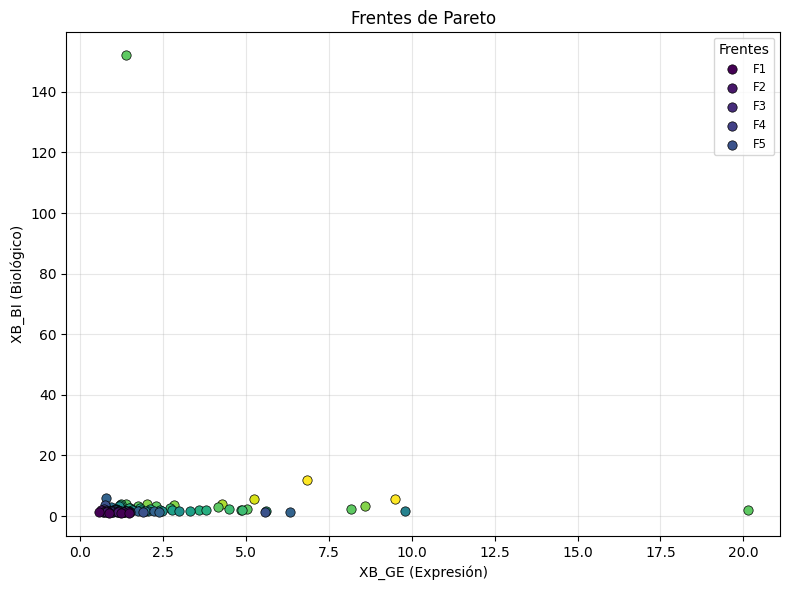

Frentes encontrados: 17
  F1: 4 soluciones → índices [19, 44, 61, 87]
  F2: 8 soluciones → índices [7, 17, 25, 36, 53, 58, 64, 84]
  F3: 8 soluciones → índices [0, 3, 43, 56, 57, 59, 71, 95]
  F4: 8 soluciones → índices [30, 38, 91, 14, 65, 27, 78, 96]
  F5: 9 soluciones → índices [70, 29, 77, 11, 33, 54, 23, 34, 94]
  F6: 11 soluciones → índices [55, 6, 12, 40, 13, 63, 8, 16, 32, 9, 52]
  F7: 7 soluciones → índices [79, 88, 20, 37, 48, 66, 90]
  F8: 6 soluciones → índices [21, 28, 60, 89, 86, 98]
  F9: 5 soluciones → índices [42, 62, 67, 24, 1]
  F10: 5 soluciones → índices [80, 41, 83, 39, 97]
  F11: 8 soluciones → índices [15, 47, 5, 68, 69, 50, 45, 93]
  F12: 6 soluciones → índices [22, 73, 82, 92, 10, 51]
  F13: 8 soluciones → índices [74, 99, 75, 81, 18, 72, 85, 26]
  F14: 3 soluciones → índices [76, 31, 2]
  F15: 1 soluciones → índices [46]
  F16: 1 soluciones → índices [49]
  F17: 2 soluciones → índices [4, 35]


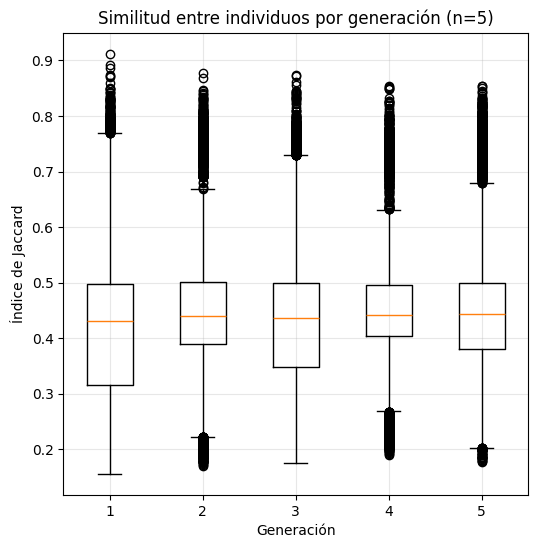


── Índice de Jaccard por generación ──
Generación 1: min=0.1562  mean=0.4399  max=0.9120
Generación 2: min=0.1693  mean=0.4578  max=0.8768
Generación 3: min=0.1754  mean=0.4425  max=0.8732
Generación 4: min=0.1907  mean=0.4624  max=0.8544
Generación 5: min=0.1776  mean=0.4533  max=0.8543

── Hipervolumen por individuo (referencia (1,1)) ──
Individuo 1: HV = 1.147055
Individuo 2: HV = 3.036181
Individuo 3: HV = 27.385066
Individuo 4: HV = 1.767044
Individuo 5: HV = 54.347549
Individuo 6: HV = 6.798582
Individuo 7: HV = 8.773020
Individuo 8: HV = 1.175963
Individuo 9: HV = 2.102404
Individuo 10: HV = 1.890728
Individuo 11: HV = 7.237986
Individuo 12: HV = 2.647441
Individuo 13: HV = 1.863566
Individuo 14: HV = 3.360157
Individuo 15: HV = 1.936975
Individuo 16: HV = 4.269750
Individuo 17: HV = 1.904971
Individuo 18: HV = 1.306849
Individuo 19: HV = 18.446544
Individuo 20: HV = 1.384738
Individuo 21: HV = 2.235060
Individuo 22: HV = 2.353324
Individuo 23: HV = 4.760161
Individuo 24: HV = 

In [6]:


N_GENERATIONS = 5   # placeholder: aún no existe el loop real de generaciones (vive en MOC_1.py)

# ── 1. Objetivos de la población base ───────────────────────────────────────
labels_pop = build_clusters_population(deb_matrix, population)  # asignación compartida (expresión) para XB_GE y XB_BI

xb_pairs = np.array([
    xie_beni(deb_matrix, dbb_matrix, population[i], labels_pop[i])
    for i in range(POP_SIZE)
])
xb_deb_pop, xb_dbb_pop = xb_pairs[:, 0], xb_pairs[:, 1]
objectives = xb_pairs   # shape (pop_size, 2): col 0 = XB_GE, col 1 = XB_BI

# ── 2. Frentes de Pareto (obligatorio como entrada de plot_pareto_fronts) ───
fronts = non_dominated_sort(objectives)

# ── 3. Generaciones simuladas para jaccard_population ───────────────────────
# NOTA: aún no hay un ciclo real de generaciones en este notebook; se simulan
# N_GENERATIONS poblaciones independientes solo para validar la función.
# Reemplazar por las poblaciones reales de cada generación cuando se integre
# con el ciclo completo de la metaheurística (MOC_1.py).
generations_labels = []
for gen in range(N_GENERATIONS):
    gen_population = random_medoids_pop(n=n, k=K, pop_size=POP_SIZE, seed=SEED + gen)
    gen_labels = build_clusters_population(deb_matrix, gen_population)
    generations_labels.append(gen_labels)

##################################
# Resultados por pantalla
##################################
plot_pareto_fronts(objectives, fronts=fronts, output_dir=None, show=True)

print(f"Frentes encontrados: {len(fronts)}")
for rank, front in enumerate(fronts):
    print(f"  F{rank + 1}: {len(front)} soluciones → índices {front}")

jaccard_values_per_gen = jaccard_population(generations_labels)
print("\n── Índice de Jaccard por generación ──")
for gen, vals in enumerate(jaccard_values_per_gen):
    print(f"Generación {gen + 1}: min={vals.min():.4f}  mean={vals.mean():.4f}  max={vals.max():.4f}")

hv_values = hypervolume_from_origin(xb_deb_pop, xb_dbb_pop)
print("\n── Hipervolumen por individuo (referencia (1,1)) ──")
for i, hv in enumerate(hv_values):
    print(f"Individuo {i + 1}: HV = {hv:.6f}")
print(f"\nHipervolumen total (suma) = {hv_values.sum():.6f}")

## Código final NSGA-II

In [ ]:
def evaluate_population(
    population: np.ndarray,
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
    max_obj_function_calls: int | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Evalúa (XB_GE, XB_BI) para una población de medoides.

    Si max_obj_function_calls no es None, evalúa como máximo
    (max_obj_function_calls - OBJ_FUNCTION_CALLS) individuos, truncando
    la población de entrada si es necesario — garantiza que el total de
    llamadas a la función objetivo nunca supere el máximo, ni por una sola.

    Retorna
    -------
    evaluated_population : np.ndarray — subconjunto de `population` realmente evaluado (puede ser más chico que la entrada).
    objectives            : np.ndarray shape (m, 2).
    labels_pop            : np.ndarray shape (m, n).
    """
    pop_size = population.shape[0]

    if max_obj_function_calls is not None:
        remaining = max_obj_function_calls - OBJ_FUNCTION_CALLS
        pop_size = max(0, min(pop_size, remaining))

    evaluated_population = population[:pop_size]

    if pop_size == 0:
        return evaluated_population, np.empty((0, 2)), np.empty((0, deb_matrix.shape[0]), dtype=np.int32)

    labels_pop = build_clusters_population(deb_matrix, evaluated_population)
    objectives = np.array([
        xie_beni(deb_matrix, dbb_matrix, evaluated_population[i], labels_pop[i])
        for i in range(pop_size)
    ])
    return evaluated_population, objectives, labels_pop

def compute_ranks_and_crowding(objectives: np.ndarray) -> tuple[np.ndarray, np.ndarray, list[list[int]]]:
    """
    Convierte la salida de non_dominated_sort/crowding_distance (indexada
    por frente) en arreglos planos indexados por posición en la población,
    formato que requiere binary_tournament_selection.
    """
    fronts = non_dominated_sort(objectives)
    pop_size = len(objectives)
    ranks = np.empty(pop_size, dtype=np.int32)
    crowding = np.empty(pop_size, dtype=np.float64)

    for rank, front in enumerate(fronts):
        dist = crowding_distance(objectives, front)
        for idx in front:
            ranks[idx] = rank
            crowding[idx] = dist[idx]

    return ranks, crowding, fronts

def _ensure_unique(
    individual: np.ndarray,
    existing_sets: set[frozenset],
    n: int,
    k: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Si `individual` ya existe en `existing_sets` (mismo conjunto de medoides,
    sin importar el orden — un cromosoma es un conjunto, no una secuencia),
    lo reemplaza por un individuo nuevo generado al azar hasta encontrar uno
    que no esté repetido. Registra el resultado en `existing_sets` (in-place).

    Parámetros
    ----------
    individual    : np.ndarray — candidato a verificar, shape (k,).
    existing_sets : set[frozenset] — conjuntos de medoides ya presentes en
                    la población actual + candidatos ya aceptados en esta
                    misma generación (se modifica in-place).
    n, k          : int — tamaño del dataset y número de medoides.
    rng           : np.random.Generator.

    Retorna
    -------
    np.ndarray — el individuo original si era único, o un reemplazo aleatorio
    único en caso contrario.
    """
    key = frozenset(individual.tolist())

    while key in existing_sets:
        individual = rng.choice(n, size=k, replace=False).astype(individual.dtype)
        key = frozenset(individual.tolist())

    existing_sets.add(key)
    return individual

def run_nsga2(
    deb_matrix: np.ndarray,
    dbb_matrix: np.ndarray,
    n: int,
    k: int,
    pop_size: int,
    max_obj_function_calls: int,
    crossover_prob: float = 0.80,
    mutation_prob: float = 0.01,
    seed: int | None = None,
) -> dict:
    """
    Ciclo principal de NSGA-II. Criterio de paro EXACTO: nunca se ejecuta
    una llamada a la función objetivo por sobre max_obj_function_calls —
    evaluate_population trunca la última tanda (inicial u offspring) para
    respetar el presupuesto exactamente.
    """
    rng = np.random.default_rng(seed)

    # ── Población inicial P0 (puede truncarse si el presupuesto es muy bajo) ──
    population = random_medoids_pop(n=n, k=k, pop_size=pop_size, seed=seed)
    population, objectives, labels_pop = evaluate_population(
        population, deb_matrix, dbb_matrix, max_obj_function_calls=max_obj_function_calls,
    )

    history_objectives = [objectives.copy()]
    history_labels     = [labels_pop.copy()]
    history_hv         = [hypervolume_from_origin(objectives[:, 0], objectives[:, 1])] if len(objectives) else []

    gen = 0
    while OBJ_FUNCTION_CALLS < max_obj_function_calls and len(population) >= 2:
        gen += 1
        pop_size_actual = len(population)

        # 1. Ranking + crowding de la población actual.
        ranks, crowding, _ = compute_ranks_and_crowding(objectives)

        # 2. Selección de padres (torneo binario).
        parents = binary_tournament_selection(population, ranks, crowding, n_offspring=pop_size_actual, rng=rng)

        # 3. Crossover + mutación → candidatos a descendencia Qv (aún sin evaluar).
        existing_sets = {frozenset(ind.tolist()) for ind in population}

        offspring_candidates = np.empty_like(parents)
        for i in range(0, pop_size_actual - 1, 2):
            c1, c2 = k_point_crossover(parents[i], parents[i + 1], n=n, crossover_prob=crossover_prob, rng=rng)
            c1 = controller_random_mutation(c1, n=n, mutation_prob=mutation_prob, rng=rng)
            c2 = controller_random_mutation(c2, n=n, mutation_prob=mutation_prob, rng=rng)
            offspring_candidates[i]     = _ensure_unique(c1, existing_sets, n, k, rng)
            offspring_candidates[i + 1] = _ensure_unique(c2, existing_sets, n, k, rng)
        if pop_size_actual % 2 == 1:
            c_last = controller_random_mutation(parents[-1].copy(), n=n, mutation_prob=mutation_prob, rng=rng)
            offspring_candidates[-1] = _ensure_unique(c_last, existing_sets, n, k, rng)

        # 4. Evaluación truncada exactamente al presupuesto restante.
        offspring, offspring_objectives, offspring_labels = evaluate_population(
            offspring_candidates, deb_matrix, dbb_matrix, max_obj_function_calls=max_obj_function_calls,
        )

        if len(offspring) == 0:
            break  # presupuesto agotado antes de evaluar algún hijo

        # 5. Rv = Pv ∪ Qv (evaluada).
        combined_population = np.vstack([population, offspring])
        combined_objectives = np.vstack([objectives, offspring_objectives])
        combined_labels     = np.vstack([labels_pop, offspring_labels])

        # 6. Ranking + crowding de Rv, y construcción de Pv+1.
        _, combined_crowding, combined_fronts = compute_ranks_and_crowding(combined_objectives)

        target_size = min(pop_size, len(combined_population))
        next_indices: list[int] = []
        for front in combined_fronts:
            if len(next_indices) + len(front) <= target_size:
                next_indices.extend(front)
            else:
                remaining_slots = target_size - len(next_indices)
                front_sorted = sorted(front, key=lambda idx: combined_crowding[idx], reverse=True)
                next_indices.extend(front_sorted[:remaining_slots])
                break

        population = combined_population[next_indices]
        objectives = combined_objectives[next_indices]
        labels_pop = combined_labels[next_indices]

        history_objectives.append(objectives.copy())
        history_labels.append(labels_pop.copy())
        history_hv.append(hypervolume_from_origin(objectives[:, 0], objectives[:, 1]))

        f1_size = len(non_dominated_sort(objectives)[0])
        mean_hv = np.mean(history_hv[-1])
        print(f"[gen {gen:>3}] llamadas = {OBJ_FUNCTION_CALLS:>6}/{max_obj_function_calls}  |  población = {len(population)}  |  F1 = {f1_size}  |  HV promedio = {mean_hv:.6f}")

    print(f"\nCriterio de paro EXACTO: {OBJ_FUNCTION_CALLS}/{max_obj_function_calls} llamadas a la función objetivo, {gen} generaciones completadas.")

    return {
        "population":         population,
        "objectives":         objectives,
        "labels":             labels_pop,
        "fronts":             non_dominated_sort(objectives),
        "history_objectives": history_objectives,
        "history_labels":     history_labels,
        "history_hv":         history_hv,
        "history_hv_mean":    [float(np.mean(hv)) for hv in history_hv],
        "generations_run":    gen,
    }

[gen   1] llamadas =    100/3000  |  población = 50  |  F1 = 2  |  HV promedio = 1.770132  |  HV F1 promedio = 1.959502
[gen   2] llamadas =    150/3000  |  población = 50  |  F1 = 2  |  HV promedio = 1.762667  |  HV F1 promedio = 0.541695
[gen   3] llamadas =    200/3000  |  población = 50  |  F1 = 3  |  HV promedio = 1.506336  |  HV F1 promedio = 0.704253
[gen   4] llamadas =    250/3000  |  población = 50  |  F1 = 3  |  HV promedio = 1.448959  |  HV F1 promedio = 0.704253
[gen   5] llamadas =    300/3000  |  población = 50  |  F1 = 5  |  HV promedio = 1.507214  |  HV F1 promedio = 0.736293
[gen   6] llamadas =    350/3000  |  población = 50  |  F1 = 5  |  HV promedio = 1.362950  |  HV F1 promedio = 0.736293
[gen   7] llamadas =    400/3000  |  población = 50  |  F1 = 5  |  HV promedio = 1.333362  |  HV F1 promedio = 0.736293
[gen   8] llamadas =    450/3000  |  población = 50  |  F1 = 5  |  HV promedio = 1.247308  |  HV F1 promedio = 0.666085
[gen   9] llamadas =    500/3000  |  pob

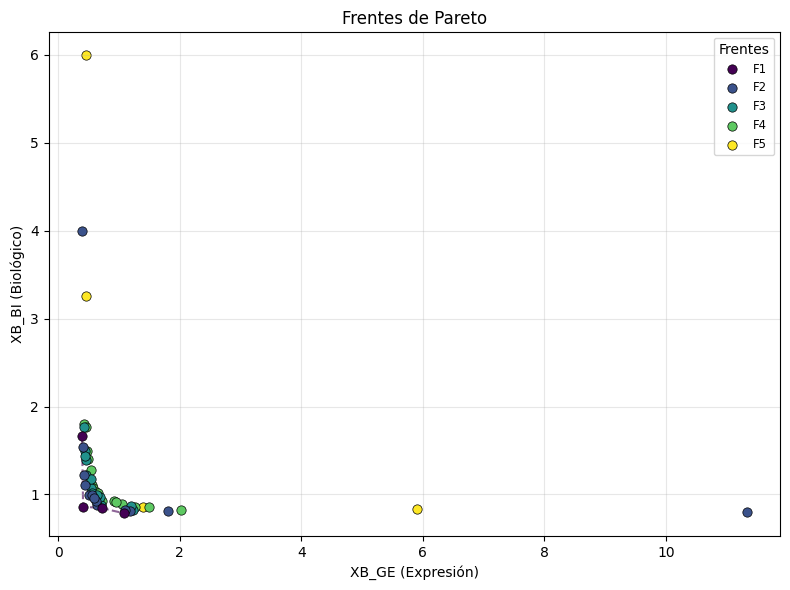

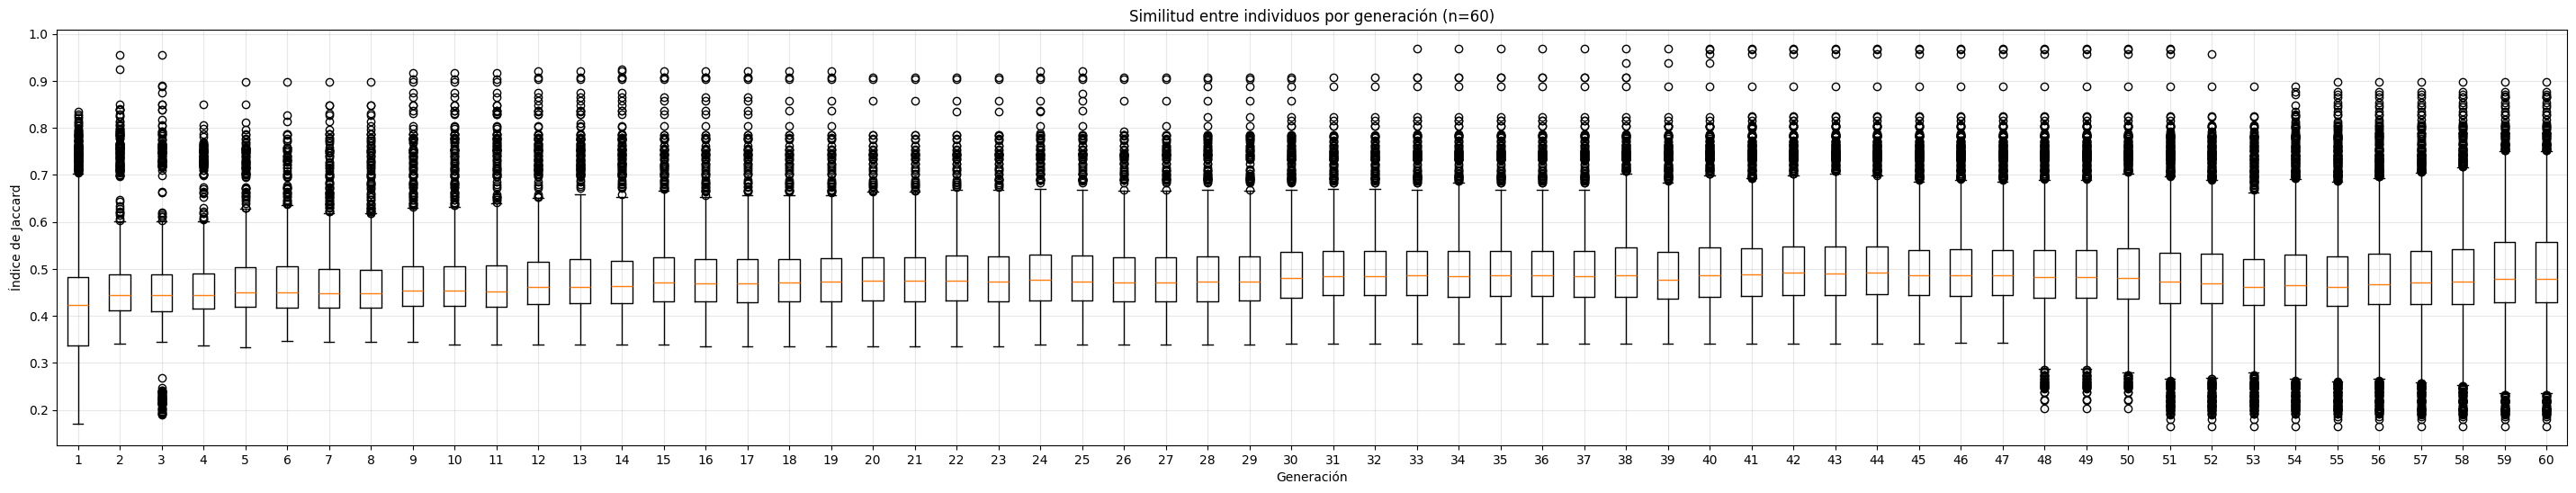

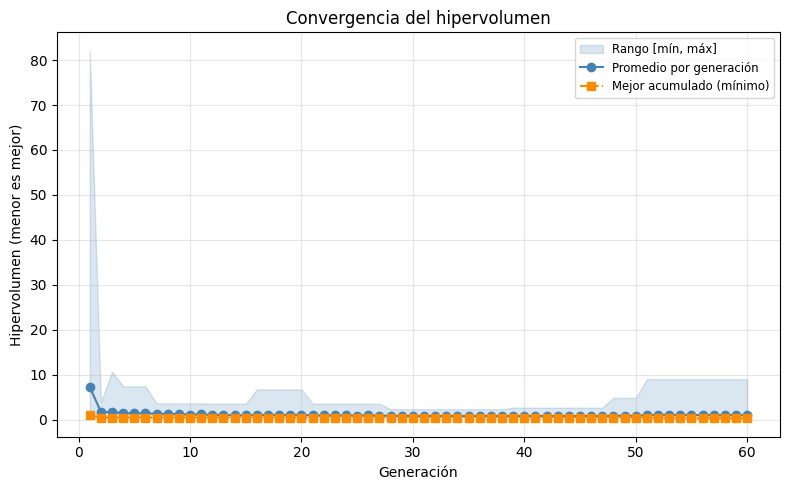


Llamadas totales a la función objetivo: 3000
Generaciones ejecutadas: 59
Frentes en la población final: 5
F1 (no dominado): 4 soluciones


In [19]:
##################################
# Bloque de ejecución: NSGA-II completo
##################################
MAX_OBJ_FUNCTION_CALLS = 3000   # presupuesto total de evaluaciones
POP_SIZE = 50
CROSSOVER_PROB = 0.80
MUTATION_PROB  = 0.01

OBJ_FUNCTION_CALLS = 0
result = run_nsga2(
    deb_matrix, dbb_matrix,
    n=n, k=K,
    pop_size=POP_SIZE,
    max_obj_function_calls=MAX_OBJ_FUNCTION_CALLS,
    crossover_prob=CROSSOVER_PROB,
    mutation_prob=MUTATION_PROB,
    seed=SEED,
)

##################################
# Resultados por pantalla
##################################
plot_pareto_fronts(result["objectives"], fronts=result["fronts"], show=True)
jaccard_population(result["history_labels"])
plot_hypervolume_convergence(result["history_hv"], show=True)

print(f"\nLlamadas totales a la función objetivo: {OBJ_FUNCTION_CALLS}")
print(f"Generaciones ejecutadas: {result['generations_run']}")
print(f"Frentes en la población final: {len(result['fronts'])}")
print(f"F1 (no dominado): {len(result['fronts'][0])} soluciones")